In [2]:
import pandas as pd
import numpy as np

# 1. Load your actual collected data
# Assuming filenames from your VS Code explorer screenshot
try:
    df_n = pd.read_csv('dataset/motor_data_normal.csv')
    df_l = pd.read_csv('dataset/motor_data_likely_faulty.csv')
    df_f = pd.read_csv('dataset/motor_data_faulty.csv')
except FileNotFoundError as e:
    print(f"Error: Ensure CSimportV files are in the same directory. {e}")

# Features we want to replicate
cols = ['ax', 'ay', 'az', 'vibration']

def generate_class_data(source_df, label_value, num_samples):
    """
    Analyzes the source CSV and replicates its statistical DNA 
    to create a massive synthetic batch.
    """
    # Calculate Mean and Std Dev for this specific condition
    analysis = source_df[cols].agg(['mean', 'std'])
    
    generated_data = pd.DataFrame()
    for col in cols:
        m = analysis.loc['mean', col]
        s = analysis.loc['std', col]
        
        # Generating synthetic values based on REAL distributions
        # We use a small 'jitter' factor (1.05) to slightly broaden 
        # the variance for better model generalization.
        generated_data[col] = np.random.normal(loc=m, scale=s * 1.05, size=num_samples)
    
    generated_data['label'] = label_value
    return generated_data

# --- SET YOUR TARGET SIZE ---
# 100,000 samples per class = 300,000 total rows for a robust CNN
samples_per_class = 5000000 

print("Generating huge synthetic dataset...")

# Create the three balanced datasets
df_huge_normal = generate_class_data(df_n, 0, samples_per_class)
df_huge_likely = generate_class_data(df_l, 1, samples_per_class)
df_huge_faulty = generate_class_data(df_f, 2, samples_per_class)

# 2. Merge, Shuffle, and Export
df_huge_final = pd.concat([df_huge_normal, df_huge_likely, df_huge_faulty], ignore_index=True)

# Shuffle the data so the model doesn't learn the order
df_huge_final = df_huge_final.sample(frac=1).reset_index(drop=True)

df_huge_final.to_csv('huge_balanced_motor_dataset.csv', index=False)

print(f"✅ Success! Dataset saved with {len(df_huge_final)} rows.")
print(df_huge_final.groupby('label').size())

Generating huge synthetic dataset...
✅ Success! Dataset saved with 15000000 rows.
label
0    5000000
1    5000000
2    5000000
dtype: int64


In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle

# --- 1. Load the Massive Balanced Dataset ---
# Use the huge dataset generated in the previous step
df = pd.read_csv('huge_balanced_motor_dataset.csv')

# Features: ax, ay, az, vibration (gx, gy, gz removed if not collected in real data)
features = ['ax', 'ay', 'az', 'vibration']
X_raw = df[features].values
y_raw = df['label'].values

# --- 2. Scaling (CRITICAL for Neural Networks) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Save the scaler parameters! You will need these for your ESP32 C++ code.
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f"Mean: {scaler.mean_} | Std: {scaler.scale_}")

# --- 3. Advanced Windowing Function ---
def create_windows(X, y, window_size=100, step_size=50):
    X_windows, y_windows = [], []
    for i in range(0, len(X) - window_size, step_size):
        X_windows.append(X[i:i + window_size])
        # Majority vote for the label in the window
        y_windows.append(np.bincount(y[i:i + window_size]).argmax())
    return np.array(X_windows), np.array(y_windows)

# Increase window_size to 128 (Powers of 2 are more efficient for Edge AI)
WINDOW_SIZE = 128 
X_win, y_win = create_windows(X_scaled, y_raw, window_size=WINDOW_SIZE, step_size=64)

# Stratified split ensures equal representation of labels in Test set
X_train, X_test, y_train, y_test = train_test_split(
    X_win, y_win, test_size=0.2, random_state=42, stratify=y_win
)

# --- 4. The "Specimen" 1D-CNN Model ---
def create_motor_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        # Block 1: Local Feature Extraction
        layers.Conv1D(32, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),
        
        # Block 2: Broader Temporal Patterns
        layers.Conv1D(64, kernel_size=5, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(), # Aggregates features for class decision
        
        # Output Head
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3), # Prevents overfitting to synthetic noise
        layers.Dense(num_classes, activation='softmax') 
    ])
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Initialize and Train
input_dim = (X_train.shape[1], X_train.shape[2]) # (128, 4)
num_classes = 3 # 0: Normal, 1: Likely Faulty, 2: Faulty

model = create_motor_model(input_dim, num_classes)
model.summary()

# Training with Early Stopping to prevent over-learning synthetic data
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train, 
    epochs=50, 
    batch_size=64, 
    validation_split=0.15,
    callbacks=[early_stop]
)

# --- 5. Export for ESP32 ---
model.save('motor_condition_model.h5')

# Convert to TFLite (the final step for Edge AI)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('motor_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ Model trained and converted to TFLite.")

Mean: [-0.68711083  1.09766283  1.34212634  0.51730766] | Std: [ 2.61964209 85.55473151 29.76633909 63.45644173]


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 32)        │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,283 (51.89 KB)

 Trainable params: 13,091 (51.14 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/50
2491/2491 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.7155 - loss: 0.6458 - val_accuracy: 0.7755 - val_loss: 0.5091
Epoch 2/50
2491/2491 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.7852 - loss: 0.5032 - val_accuracy: 0.7827 - val_loss: 0.4970
Epoch 3/50
2491/2491 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - accuracy: 0.8028 - loss: 0.4627 - val_accuracy: 0.8126 - val_loss: 0.4273
Epoch 4/50
2491/2491 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - accuracy: 0.8134 - loss: 0.4391 - val_accuracy: 0.8110 - val_loss: 0.4335
Epoch 5/50
2491/2491 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - accuracy: 0.8210 - loss: 0.4203 - val_accuracy: 0.8183 - val_loss: 0.4224
Epoch 6/50
2491/2491 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - accuracy: 0.8295 - loss: 0.4031 - val_accuracy: 0.7876 - val_loss: 0.5210
Epoch 7/50
2491/2491 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - accuracy: 0.8335 - loss: 0.3930 - val_accuracy: 0.7433 - val_loss: 0.6680
Epoch 8/50
2491/2491 ━━━━━━━━━━━━━━━━━━━━ 39s 16ms/step - accuracy: 0.8378 -

INFO:tensorflow:Assets written to: C:\Users\USER\AppData\Local\Temp\tmptaedq7pq\assets


INFO:tensorflow:Assets written to: C:\Users\USER\AppData\Local\Temp\tmptaedq7pq\assets


Saved artifact at 'C:\Users\USER\AppData\Local\Temp\tmptaedq7pq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 4), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1932149855456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1932150388192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1932150380096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1932150389600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1932150385904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1932150388368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1932150388896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1932193205760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1932193205584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1932193202768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  19321932048

In [4]:
import os
import pickle
import tensorflow as tf
from sklearn.metrics import classification_report

# --- 1. Evaluate the Model (Fixes the NameError) ---
# This ensures test_loss and test_acc are defined before saving
print("Final Evaluation on Test Set...")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)

# Generate predictions for the detailed report
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# --- 2. Save the Trained Model (.h5) ---
model_ver = "v2_3class_motor"
model_h5_name = f'mpu5060_cnn_{model_ver}.h5'
model.save(model_h5_name)
print(f"✅ Keras Model saved as {model_h5_name}")

# --- 3. Convert to TFLite (The format for ESP32) ---
# Using optimization to shrink the model size for microcontroller memory
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_name = f'motor_model_{model_ver}.tflite'
with open(tflite_name, 'wb') as f:
    f.write(tflite_model)
print(f"✅ TFLite Model saved as {tflite_name}")

# --- 4. Save Comprehensive Metrics & Scaler Data ---
report = classification_report(y_test, y_pred, target_names=['Normal', 'Likely', 'Faulty'])

with open('model_metrics_final.txt', 'w') as f:
    f.write(f"--- Motor Model Performance ({model_ver}) ---\n")
    f.write(f"Final Test Accuracy: {test_acc*100:.2f}%\n")
    f.write(f"Final Test Loss: {test_loss:.4f}\n\n")
    f.write("--- Detailed Class Report ---\n")
    f.write(report)
    
    # Very Important: Saving Scaler Params for your ESP32 C++ Code
    if 'scaler' in locals():
        f.write("\n--- Scaler Parameters for C++ Implementation ---\n")
        f.write(f"Mean Values: {scaler.mean_.tolist()}\n")
        f.write(f"Std Dev (Scale): {scaler.scale_.tolist()}\n")
        f.write("\nFormula: (input - mean) / std_dev\n")

print("✅ All artifacts saved. Ready for Edge deployment.")

Final Evaluation on Test Set...
1465/1465 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8503 - loss: 0.3452
1465/1465 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


✅ Keras Model saved as mpu5060_cnn_v2_3class_motor.h5
INFO:tensorflow:Assets written to: C:\Users\USER\AppData\Local\Temp\tmppm_d8i4w\assets


INFO:tensorflow:Assets written to: C:\Users\USER\AppData\Local\Temp\tmppm_d8i4w\assets


Saved artifact at 'C:\Users\USER\AppData\Local\Temp\tmppm_d8i4w'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 4), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1932149855456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1932150388192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1932150380096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1932150389600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1932150385904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1932150388368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1932150388896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1932193205760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1932193205584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1932193202768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  19321932048

1465/1465 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


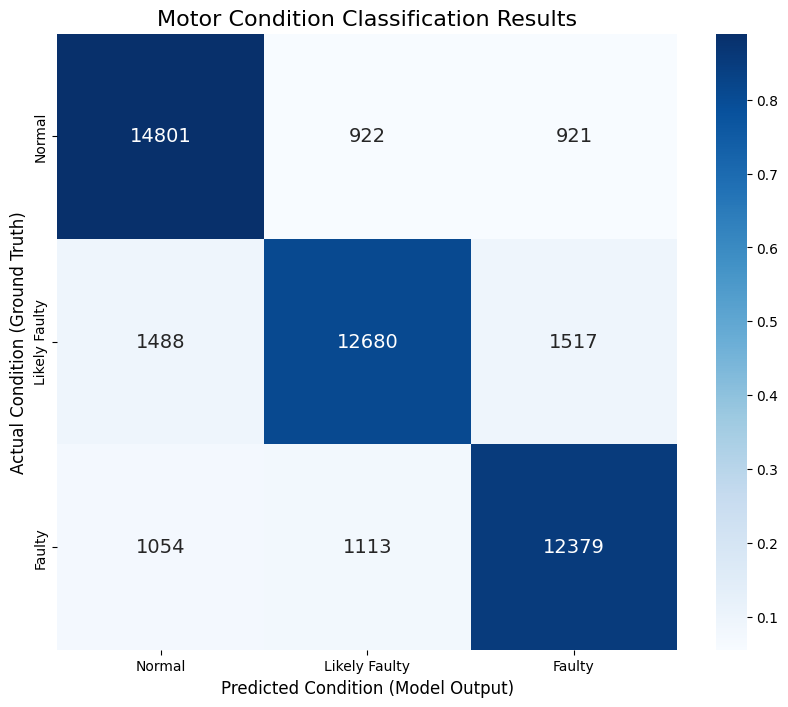


--- Detailed Classification Report ---
               precision    recall  f1-score   support

       Normal       0.85      0.89      0.87     16644
Likely Faulty       0.86      0.81      0.83     15685
       Faulty       0.84      0.85      0.84     14546

     accuracy                           0.85     46875
    macro avg       0.85      0.85      0.85     46875
 weighted avg       0.85      0.85      0.85     46875



In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get predictions from the test set
# model.predict returns probabilities; argmax picks the class with highest %
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Define our 3-class labels in order (0, 1, 2)
class_names = ['Normal', 'Likely Faulty', 'Faulty']

# 3. Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Calculate percentages for a clearer view (Normalized CM)
cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# 4. Plotting
plt.figure(figsize=(10, 8))

# We use the percentage matrix for the colors but show the raw counts as text
sns.heatmap(cm_perc, annot=cm, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names,
            annot_kws={"size": 14})

plt.title('Motor Condition Classification Results', fontsize=16)
plt.ylabel('Actual Condition (Ground Truth)', fontsize=12)
plt.xlabel('Predicted Condition (Model Output)', fontsize=12)
plt.show()

# 5. Print detailed report (Precision, Recall, F1-Score)
print("\n--- Detailed Classification Report ---")
# Providing target_names makes the report much easier to read
print(classification_report(y_test, y_pred, target_names=class_names))